In [68]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score,GridSearchCV,RandomizedSearchCV,train_test_split
from sklearn.metrics import accuracy_score,recall_score,confusion_matrix,classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

import pickle

In [4]:
churn_df = pd.read_csv(r"C:\Users\MALCOM_TREVOR\Desktop\DATA SCIENCE\MY PROJECT\ML\Classification Tasks\bank churn\data\bank_churn_train.csv",index_col='CustomerId',comment ='#')

In [5]:
churn_df.shape

(8899, 13)

In [8]:
churn_df.head()

,RowNumber,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
CustomerId,,,,,,,,,,,,,
15647311,2,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
15619304,3,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
15701354,4,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
15737888,5,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
15574012,6,Chu,645,Spain,Male,44,8,113755.78,2,1,0,149756.71,1


## Data preprocessing

In [13]:
churn_df = churn_df.rename(columns={'Geography':'Country_lived','Tenure':'Time_worked_with_bank(yrs)',
                                  'NumOfProducts':'Products_Obtained_through_bank',
                                  'EstimatedSalary':'Estimated_Salary','IsActiveMember':'Is_Active_Member',
                                  'HasCrCard':'Has_CrCard'})
churn_df.Country_lived = churn_df.Country_lived.map({'France':1,'Spain':2,'Germany':3})
churn_df.Gender = churn_df.Gender.map({'Female':1,'Male':2})

In [14]:
churn_df

,RowNumber,Surname,CreditScore,Country_lived,Gender,Age,Time_worked_with_bank(yrs),Balance,Products_Obtained_through_bank,Has_CrCard,Is_Active_Member,Estimated_Salary,Exited
CustomerId,,,,,,,,,,,,,
15647311,2,Hill,608,2,1,41,1,83807.86,1,0,1,112542.58,0
15619304,3,Onio,502,1,1,42,8,159660.80,3,1,0,113931.57,1
15701354,4,Boni,699,1,1,39,1,0.00,2,0,0,93826.63,0
15737888,5,Mitchell,850,2,1,43,2,125510.82,1,1,1,79084.10,0
15574012,6,Chu,645,2,2,44,8,113755.78,2,1,0,149756.71,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
15658972,8896,Foster,699,1,1,40,8,122038.34,1,1,0,102085.35,0
15724691,8897,Gordon,712,1,2,34,1,0.00,2,1,1,195052.12,0
15740442,8898,May,603,1,2,51,8,186825.57,1,1,0,93739.71,1


## Feature selection

In [29]:
churn_df[['CreditScore','Age','Time_worked_with_bank(yrs)','Balance','Products_Obtained_through_bank','Estimated_Salary','Exited']].corr()['Exited']

CreditScore                      -0.027294
Age                               0.290172
Time_worked_with_bank(yrs)       -0.011847
Balance                           0.122308
Products_Obtained_through_bank   -0.050064
Estimated_Salary                  0.015503
Exited                            1.000000
Name: Exited, dtype: float64

In [31]:
x = churn_df.drop(['Exited','Surname','RowNumber'],axis = 1)
y = churn_df.Exited

In [33]:
x

,CreditScore,Country_lived,Gender,Age,Time_worked_with_bank(yrs),Balance,Products_Obtained_through_bank,Has_CrCard,Is_Active_Member,Estimated_Salary
CustomerId,,,,,,,,,,
15647311,608,2,1,41,1,83807.86,1,0,1,112542.58
15619304,502,1,1,42,8,159660.80,3,1,0,113931.57
15701354,699,1,1,39,1,0.00,2,0,0,93826.63
15737888,850,2,1,43,2,125510.82,1,1,1,79084.10
15574012,645,2,2,44,8,113755.78,2,1,0,149756.71
...,...,...,...,...,...,...,...,...,...,...
15658972,699,1,1,40,8,122038.34,1,1,0,102085.35
15724691,712,1,2,34,1,0.00,2,1,1,195052.12
15740442,603,1,2,51,8,186825.57,1,1,0,93739.71


In [35]:
y

CustomerId
15647311    0
15619304    1
15701354    0
15737888    0
15574012    1
           ..
15658972    0
15724691    0
15740442    1
15760427    0
15677939    0
Name: Exited, Length: 8899, dtype: int64

## Model Selection

#### Comparing the model with default hyperparameters

In [ ]:
models = [LogisticRegression(),DecisionTreeClassifier(),RandomForestClassifier(),SVC()]
for model in models:
    scores = cross_val_score(model,x,y,cv = 5)
    print(f"Model: {model}\nScores for 5 sets:{scores}\nScore: {scores.mean().round(2)}")
    print("*****"*10)

### Hyperparameter Tuning , Grid Search or Randomized Search

#### Logistic Regression

In [84]:
# Hyperparameters
parameters_lg = {
    'C':[1,5,10],
    'penalty':['l1','l2']
    }

# perform grid search
grid_search_lg = GridSearchCV(LogisticRegression(random_state = 0),parameters_lg,cv = 5)

# fit it on x and y
grid_search_lg.fit(x,y)

GridSearchCV(cv=5, estimator=LogisticRegression(random_state=0),
             param_grid={'C': [1, 5, 10], 'penalty': ['l1', 'l2']})

In [85]:
# best parameters and the best score
print(f"Best parameters for Logistic Regression :{grid_search_lg.best_params_}\nBest Score for this model:{grid_search_lg.best_score_}")

Best parameters for Logistic Regression :{'C': 1, 'penalty': 'l2'}
Best Score for this model:0.7931224460149939


In [89]:
result_lg = pd.DataFrame(grid_search_lg.cv_results_)
result_lg = result_lg[['param_C','param_penalty','params','mean_test_score']]
result_lg.nlargest(5,'mean_test_score')

,param_C,param_penalty,params,mean_test_score
1,1,l2,"{'C': 1, 'penalty': 'l2'}",0.793122
5,10,l2,"{'C': 10, 'penalty': 'l2'}",0.792111
3,5,l2,"{'C': 5, 'penalty': 'l2'}",0.791999
0,1,l1,"{'C': 1, 'penalty': 'l1'}",NaN
2,5,l1,"{'C': 5, 'penalty': 'l1'}",NaN


#### Decision Tree Classifier

In [138]:
# Hyperparameters
parameters_dc = {"criterion":['gini', 'entropy', 'log_loss'] , 
                 "max_depth": [3,5,8,12],
                 "max_features": ['auto','sqrt','log2',2,3,5,7,8]
                 }

# perform grid search
grid_search_dc = GridSearchCV(DecisionTreeClassifier(random_state = 100),parameters_dc,cv = 5)

# fit on x and y
grid_search_dc.fit(x,y)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=100),
             param_grid={'criterion': ['gini', 'entropy', 'log_loss'],
                         'max_depth': [3, 5, 8, 12],
                         'max_features': ['auto', 'sqrt', 'log2', 2, 3, 5, 7,
                                          8]})

In [139]:
# best parameters and the best score
print(f"Best parameters for Decision Tree Classifier :{grid_search_dc.best_params_}\nBest Score for this model:{grid_search_dc.best_score_}")

Best parameters for Decision Tree Classifier :{'criterion': 'gini', 'max_depth': 8, 'max_features': 7}
Best Score for this model:0.8553767739735111


In [143]:
results =pd.DataFrame(grid_search_dc.cv_results_)
results = results[['param_criterion','param_max_depth','param_max_features','mean_test_score']]
results.nlargest(5,'mean_test_score')

,param_criterion,param_max_depth,param_max_features,mean_test_score
22,gini,8,7,0.855377
53,entropy,8,5,0.854253
85,log_loss,8,5,0.854253
14,gini,5,7,0.853803
55,entropy,8,8,0.853018


### Random Forest Classifier

In [147]:
# Hyperparameters
parameters_rf = {
    "n_estimators":[200,500,700,900,1000,2000],
                 "criterion":['gini', 'entropy', 'log_loss'],
    "max_depth":[3,5,6,7,8,9,10],
    'max_features' :['auto','sqrt','log2',5,6,7,8,9,10],
                 }

# perform randomized search
random_search_rf = RandomizedSearchCV(RandomForestClassifier(random_state = 4),parameters_rf,cv = 5)

# fit it on x and y
random_search_rf.fit(x,y)

RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(random_state=4),
                   param_distributions={'criterion': ['gini', 'entropy',
                                                      'log_loss'],
                                        'max_depth': [3, 5, 6, 7, 8, 9, 10],
                                        'max_features': ['auto', 'sqrt', 'log2',
                                                         5, 6, 7, 8, 9, 10],
                                        'n_estimators': [200, 500, 700, 900,
                                                         1000, 2000]})

In [149]:
# best parameters and the best score
print(f"Best parameters for Random Forest Classifier :{random_search_rf.best_params_}\nBest Score for this model:{random_search_rf.best_score_}")

Best parameters for Random Forest Classifier :{'n_estimators': 200, 'max_features': 5, 'max_depth': 10, 'criterion': 'gini'}
Best Score for this model:0.863805003442156


In [151]:
results2 = pd.DataFrame(random_search_rf.cv_results_)
results2 = results2[['param_criterion','param_max_depth','param_n_estimators','param_max_features','mean_test_score']]
results2.nlargest(5,'mean_test_score')

,param_criterion,param_max_depth,param_n_estimators,param_max_features,mean_test_score
6,gini,10,200,5,0.863805
4,entropy,9,200,7,0.863805
7,log_loss,7,700,8,0.861782
0,log_loss,7,900,6,0.861220
8,log_loss,7,700,6,0.861220


### Support Vector Classifier

In [ ]:
# Hyperparameters
parameters_svc = {'C':[1,5,10],
                  'kernel':['linear', 'poly','rbf', 'sigmoid']
                  }
# perform randomized search
random_search_svc = RandomizedSearchCV(SVC(random_state = 0),parameters_svc,cv = 3)
#fit on x and y
random_search_svc.fit(x,y)

In [ ]:
# best parameters and the best score
print(f"Best parameters for Support Vector Classifier :{random_search_svc.best_params_}\nBest Score for this model:{random_search_svc.best_score_}")

# Model Development

In [37]:
# splitting the dataset using the train_test_split method
x_train,x_test,y_train,y_test = train_test_split(x,y,train_size = 0.8,stratify = y)

#### Random Forest Classifier

In [40]:
rf = RandomForestClassifier(max_depth=70, max_features=3, n_estimators=1000)

In [311]:
rf.fit(x_train,y_train)

RandomForestClassifier(max_depth=70, max_features=3, n_estimators=1000)

In [312]:
pd.DataFrame(rf.feature_importances_, index=x.columns).style.background_gradient(cmap ='Reds')

,0
CreditScore,0.139630
Country_lived,0.040752
Gender,0.019173
Age,0.238377
Time_worked_with_bank(yrs),0.080386
Balance,0.138552
Products_Obtained_through_bank,0.139136
Has_CrCard,0.018663
Is_Active_Member,0.041476
Estimated_Salary,0.143854


#### Decision Tree Classifier

In [58]:
dc = DecisionTreeClassifier(criterion = 'gini', max_depth = 8, max_features =  8)

In [60]:
dc.fit(x_train,y_train)

DecisionTreeClassifier(max_depth=8, max_features=8)

# Model Evaluation

### important metrics to focus on regarding to my problem
- accuracy score
- confusion matrix
- recall (False Negative is crucial to my problem and should be minimized )

In [324]:
pd.DataFrame(dc.feature_importances_,index = x.columns)

,0
CreditScore,0.018589
Country_lived,0.048559
Gender,0.009392
Age,0.366193
Time_worked_with_bank(yrs),0.016926
Balance,0.109323
Products_Obtained_through_bank,0.267270
Has_CrCard,0.003616
Is_Active_Member,0.114685
Estimated_Salary,0.045447


In [326]:
# evaluating on training set
y_train_rf = rf.predict(x_train)
print("Accuracy of the training set : ",accuracy_score(y_train,y_train_rf))

Accuracy of the training set :  1.0


In [329]:
# evaluating on testing set
y_pred_rf = rf.predict(x_test)
print("Accuracy of the testing set : ",accuracy_score(y_test,y_pred_rf))

Accuracy of the testing set :  0.8578651685393258


In [278]:
print("Recall Score of a Random Forest Classifier : ",recall_score(y_test,y_pred_rf))

Recall Score of a Random Forest Classifier :  0.46686746987951805


In [210]:
# evaluating on training set
y_train_dc = dc.predict(x_train)
print("Accuracy of the training set : ",accuracy_score(y_train,y_train_dc))

Accuracy of the training set :  0.8780727630285152


In [213]:
# evaluating on testing set
y_pred_dc = dc.predict(x_test)
print("Accuracy of the testing set : ",accuracy_score(y_test,y_pred_dc))

Accuracy of the testing set :  0.8550561797752809


In [216]:
print("Recall Score of a Random Forest Classifier : ",recall_score(y_test,y_pred_dc))

Recall Score of a Random Forest Classifier :  0.5254691689008043


In [219]:
print(classification_report(y_test,y_pred_dc))

              precision    recall  f1-score   support

           0       0.88      0.94      0.91      1407
           1       0.71      0.53      0.60       373

    accuracy                           0.86      1780
   macro avg       0.79      0.73      0.76      1780
weighted avg       0.85      0.86      0.85      1780



In [222]:
print(classification_report(y_test,y_pred_rf))

              precision    recall  f1-score   support

           0       0.88      0.96      0.92      1407
           1       0.79      0.52      0.63       373

    accuracy                           0.87      1780
   macro avg       0.84      0.74      0.77      1780
weighted avg       0.86      0.87      0.86      1780



In [225]:
cfm_dc = confusion_matrix(y_test,y_pred_dc)
cfm_dc

array([[1326,   81],
       [ 177,  196]], dtype=int64)

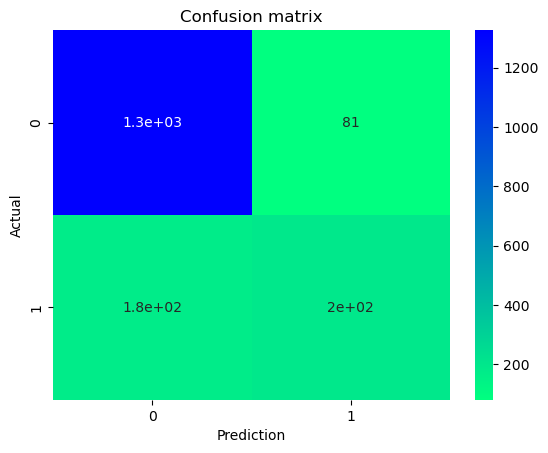

In [227]:
sns.heatmap(cfm_dc,annot = True,cmap = 'winter_r')
plt.title("Confusion matrix")
plt.xlabel("Prediction")
plt.ylabel("Actual")
plt.show()

In [ ]:
cfm_rf = confusion_matrix(y_test,y_pred_rf)
cfm_rf

In [ ]:
sns.heatmap(cfm_rf,annot = True,cmap = 'coolwarm')
plt.title("Confusion matrix")
plt.xlabel("Prediction")
plt.ylabel("Actual")
plt.show()

### evaluating using cross val

In [229]:
# Evaluating the model , checking the accuracy score
accuracy = cross_val_score(RandomForestClassifier(max_depth=70, max_features=3, n_estimators=1000),
                               x,y,cv =5,scoring = 'accuracy')
print("Accuracy Scores",accuracy)
print("Mean Accuracy Score of a Random Forest Classifier : ",accuracy.mean())

Accuracy Scores [0.86011236 0.86853933 0.86910112 0.86179775 0.86172007]
Mean Accuracy Score of a Random Forest Classifier :  0.8642541258502756


In [ ]:
# Evaluating the model , checking the recall score
recall_score = cross_val_score(RandomForestClassifier(criterion = 'entropy',max_depth = 9,max_features = 5,n_estimators = 500),
                               x,y,cv =5,scoring = 'recall_macro')
print("Recall Scores",recall_score)
print("Mean Recall Score of a Random Forest Classifier : ",recall_score.mean())

### Saving the Model for later use

In [ ]:
# with open("Random Forest Classifier Model with an accuracy of 97%",'wb') as f:
    # pickle.dump(rf,f)

## Using saved model with a 97 % accuracy

In [80]:
with open(r"C:\Users\MALCOM_TREVOR\Desktop\DATA SCIENCE\MY PROJECT\ML\Classification Tasks\bank churn\model\Random Forest Classifier Model with an accuracy of 97%",'rb') as f:
   model = pickle.load(f)

In [304]:
model

RandomForestClassifier(max_depth=70, max_features=3, n_estimators=1000)

In [88]:
# evaluating on training set
training_prediction = model.predict(x_train)
print("Accuracy of the training set : ",accuracy_score(y_train,training_prediction))

Accuracy of the training set :  0.9705014749262537


In [91]:
# evaluating on testing set
y_pred = model.predict(x_test)
print("Accuracy of the testing set : ",accuracy_score(y_test,y_pred))

Accuracy of the testing set :  0.9724719101123596


In [94]:
print("Recall Score of a Random Forest Classifier : ",recall_score(y_test,y_pred))

Recall Score of a Random Forest Classifier :  0.8940217391304348


In [97]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.97      0.99      0.98      1412
           1       0.97      0.89      0.93       368

    accuracy                           0.97      1780
   macro avg       0.97      0.94      0.96      1780
weighted avg       0.97      0.97      0.97      1780



In [100]:
cfm = confusion_matrix(y_test,y_pred)
cfm

array([[1402,   10],
       [  39,  329]], dtype=int64)

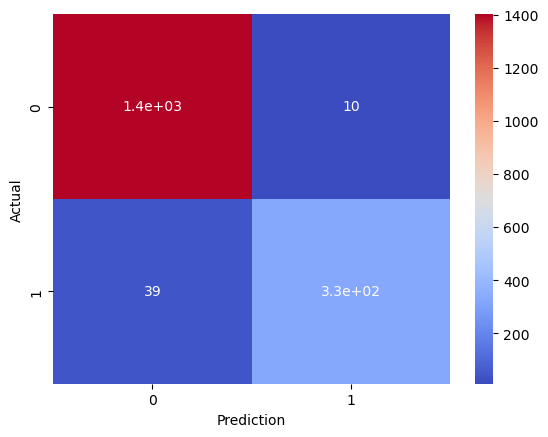

In [104]:
sns.heatmap(cfm,annot = True,cmap = 'coolwarm')
plt.xlabel("Prediction")
plt.ylabel("Actual")
plt.show()

In [106]:
pd.DataFrame(model.feature_importances_,index = x.columns).style.background_gradient()

,0
CreditScore,0.139165
Country_lived,0.040358
Gender,0.019010
Age,0.244239
Time_worked_with_bank(yrs),0.079786
Balance,0.141109
Products_Obtained_through_bank,0.129723
Has_CrCard,0.018586
Is_Active_Member,0.046334
Estimated_Salary,0.141692
